In [11]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from copy import deepcopy as dc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [12]:
print(f"PyTorch built with CUDA Version: {torch.version.cuda}")

PyTorch built with CUDA Version: 12.8


In [37]:
call_centers = ["A", "B", "C", "D"]
types = ["Daily", "Interval"]

dfs = pd.read_excel("data/Data for Datathon (Revised).xlsx", sheet_name=[
    f"{center} - {type}"
    for center in call_centers
    for type in types
])

In [38]:
# df = dfs["A - Interval"].dropna() #[["Date", "CCT"]]
center_map = {
    "A" : 0,
    "B" : 1,
    "C" : 2,
    "D" : 3
}
for c in call_centers:
    dfs[f"{c} - Interval"]["center"] = center_map[c]
    
df = pd.concat([dfs[f"{c} - Interval"] for c in call_centers]).dropna()
df

,Month,Day,Interval,Service Level,Call Volume,Abandoned Calls,Abandoned Rate,CCT,center
0,April,1,00:00:00,1.0000,5.0,0.0,0.0000,137.60,0
1,April,1,00:30:00,1.0000,5.0,0.0,0.0000,263.40,0
2,April,1,01:00:00,1.0000,4.0,0.0,0.0000,333.25,0
3,April,1,01:30:00,1.0000,3.0,0.0,0.0000,170.00,0
4,April,1,02:00:00,1.0000,1.0,0.0,0.0000,667.00,0
...,...,...,...,...,...,...,...,...,...
4353,June,30,21:30:00,0.9455,165.0,0.0,0.0000,309.20,3
4354,June,30,22:00:00,1.0000,122.0,0.0,0.0000,296.28,3
4355,June,30,22:30:00,1.0000,120.0,0.0,0.0000,271.34,3
4356,June,30,23:00:00,1.0000,76.0,1.0,0.0132,290.99,3


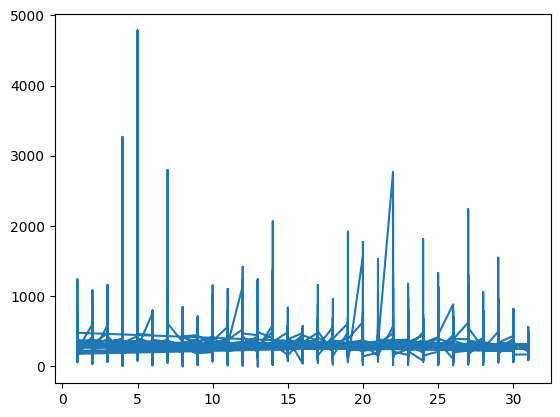

In [39]:
# plt.plot(df["Interval"], df["CCT"])
month_map = {
    "April" : 4,
    "May" : 5,
    "June" : 6
}

month = np.array([month_map[m] for m in df["Month"]])

day = df["Day"].to_numpy()

hour = []
minute = []

for dt in df["Interval"]:
    # print(dt)
    hour.append(dt.hour)
    minute.append(dt.minute)

hour, minute = [np.array(x) for x in (hour, minute)]

plt.plot(day, df["CCT"])

In [40]:
# cyclically encode date
df["month-sin"] = np.sin(2 * np.pi * month / 12)
df["month-cos"] = np.cos(2 * np.pi * month / 12)

df["day-sin"] = np.sin(2 * np.pi * day / 31)
df["day-cos"] = np.cos(2 * np.pi * day / 31)

df["hour-sin"] = np.sin(2 * np.pi * hour / 24)
df["hour-cos"] = np.cos(2 * np.pi * hour / 24)

df["minute-sin"] = np.sin(2 * np.pi * minute / 60)
df["minute-cos"] = np.cos(2 * np.pi * minute / 60)

cyclic_columns = ["month", "day", "hour", "minute"]
types = ["sin", "cos"]

out = df[["CCT"]]
features =  df[[
    f"{c}-{t}"
    for c in cyclic_columns
    for t in types
] + ["center"]]
# time_features
pd.concat((out, features), axis=1)
# out

,CCT,month-sin,month-cos,day-sin,day-cos,hour-sin,hour-cos,minute-sin,minute-cos,center
0,137.60,8.660254e-01,-0.5,0.201299,0.97953,0.000000,1.000000,0.000000e+00,1.0,0
1,263.40,8.660254e-01,-0.5,0.201299,0.97953,0.000000,1.000000,5.665539e-16,-1.0,0
2,333.25,8.660254e-01,-0.5,0.201299,0.97953,0.258819,0.965926,0.000000e+00,1.0,0
3,170.00,8.660254e-01,-0.5,0.201299,0.97953,0.258819,0.965926,5.665539e-16,-1.0,0
4,667.00,8.660254e-01,-0.5,0.201299,0.97953,0.500000,0.866025,0.000000e+00,1.0,0
...,...,...,...,...,...,...,...,...,...,...
4353,309.20,1.224647e-16,-1.0,-0.201299,0.97953,-0.707107,0.707107,5.665539e-16,-1.0,3
4354,296.28,1.224647e-16,-1.0,-0.201299,0.97953,-0.500000,0.866025,0.000000e+00,1.0,3
4355,271.34,1.224647e-16,-1.0,-0.201299,0.97953,-0.500000,0.866025,5.665539e-16,-1.0,3
4356,290.99,1.224647e-16,-1.0,-0.201299,0.97953,-0.258819,0.965926,0.000000e+00,1.0,3


In [41]:
def create_sequences(values, time_features, seq_len):
    X, y = [], []

    for i in range(len(values) - seq_len):
        seq_x = []

        for j in range(seq_len):
            timestep_features = np.concatenate([
                [values[i + j]],          # CCT
                time_features[i + j]      # time features
            ])
            seq_x.append(timestep_features)

        X.append(seq_x)
        y.append(values[i + seq_len])

    return np.array(X), np.array(y)
    
scaler = MinMaxScaler(feature_range=(-1, 1))
values = scaler.fit_transform(out.to_numpy()).flatten()
features = features.to_numpy()

X, y = create_sequences(values, features, lag := 48 * 7)

In [42]:
device = 'cuda:0' if torch.cuda.is_available else 'cpu'
device

'cuda:0'

In [43]:

X = torch.tensor(X, dtype=torch.bfloat16, device=device)
y = torch.tensor(y, dtype=torch.bfloat16, device=device)
# X = torch.tensor(shifted[:, 1:], dtype=torch.bfloat16, device=device)
# y = torch.tensor(shifted[:, 0], dtype=torch.bfloat16, device=device)

X.shape, y.shape

(torch.Size([15923, 336, 10]), torch.Size([15923]))

In [44]:
split_index = int(len(X) * .95)
split_index

15126

In [45]:
# need to add dimensions for LSTM
X_train = X[:split_index].reshape(-1, lag, 1 + 9)   # 8 additional time features + 1 centers
X_test = X[split_index:].reshape(-1, lag, 1 + 9)

y_train = y[:split_index].reshape(-1, 1)
y_test = y[split_index:].reshape(-1, 1)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([15126, 336, 10]),
 torch.Size([797, 336, 10]),
 torch.Size([15126, 1]),
 torch.Size([797, 1]))

In [46]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        return self.X[i].to(torch.bfloat16), self.y[i].to(torch.bfloat16)

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [47]:
train_dataset, test_dataset

(<__main__.TimeSeriesDataset at 0x75ecb8066b40>,
 <__main__.TimeSeriesDataset at 0x75ecb822b3b0>)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 32 # 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [49]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)

torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Size([16, 1])
torch.Size([16, 336, 10]) torch.Si

In [55]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(                    # batched first -> batch as first dimension
            input_size, 
            hidden_size, 
            num_stacked_layers, 
            batch_first=True, 
            dtype=torch.bfloat16
        )  
        
        self.fc1 = nn.Linear(hidden_size, 32, dtype=torch.bfloat16)     
        self.fc2 = nn.Linear(32, 1, dtype=torch.bfloat16)     
        # fc to map hidden size to just 1, final value

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size, dtype=torch.bfloat16).to(device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc1(out[:, -1, :])
        out = self.fc2(out)
        return out

model = LSTM(10, 64, 3)
model.to(device)
model

LSTM(
  (lstm): LSTM(10, 64, num_layers=3, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

In [56]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0], batch[1]

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 10 == 9:  # print every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [65]:
from tqdm import tqdm

learning_rate = 0.001
num_epochs = 5
# loss_function = nn.MSELoss()
def quantile_loss(y_pred, y_true, q=0.7):
    error = y_true - y_pred
    return torch.mean(torch.max(q * error, (q - 1) * error))
loss_function = lambda y_pred, y_true: quantile_loss(y_pred, y_true, q=0.7)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    train_one_epoch()
    validate_one_epoch()

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1
Batch 10, Loss: 0.002
Batch 20, Loss: 0.001
Batch 30, Loss: 0.001
Batch 40, Loss: 0.001
Batch 50, Loss: 0.001
Batch 60, Loss: 0.001
Batch 70, Loss: 0.001
Batch 80, Loss: 0.001
Batch 90, Loss: 0.001
Batch 100, Loss: 0.001
Batch 110, Loss: 0.001
Batch 120, Loss: 0.001
Batch 130, Loss: 0.001
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.001
Batch 170, Loss: 0.001
Batch 180, Loss: 0.001
Batch 190, Loss: 0.001
Batch 200, Loss: 0.002
Batch 210, Loss: 0.001
Batch 220, Loss: 0.001
Batch 230, Loss: 0.001
Batch 240, Loss: 0.001
Batch 250, Loss: 0.001
Batch 260, Loss: 0.001
Batch 270, Loss: 0.001
Batch 280, Loss: 0.001
Batch 290, Loss: 0.001
Batch 300, Loss: 0.001
Batch 310, Loss: 0.001
Batch 320, Loss: 0.001
Batch 330, Loss: 0.001
Batch 340, Loss: 0.001
Batch 350, Loss: 0.001
Batch 360, Loss: 0.001
Batch 370, Loss: 0.001
Batch 380, Loss: 0.001
Batch 390, Loss: 0.001
Batch 400, Loss: 0.001
Batch 410, Loss: 0.001
Batch 420, Loss: 0.001
Batch 430, Loss: 0.001
Batch 440, 

 20%|██        | 1/5 [00:21<01:24, 21.14s/it]

Val Loss: 0.008
***************************************************

Epoch: 2
Batch 10, Loss: 0.001
Batch 20, Loss: 0.001
Batch 30, Loss: 0.001
Batch 40, Loss: 0.001
Batch 50, Loss: 0.001
Batch 60, Loss: 0.001
Batch 70, Loss: 0.001
Batch 80, Loss: 0.001
Batch 90, Loss: 0.001
Batch 100, Loss: 0.001
Batch 110, Loss: 0.001
Batch 120, Loss: 0.001
Batch 130, Loss: 0.001
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.001
Batch 170, Loss: 0.001
Batch 180, Loss: 0.001
Batch 190, Loss: 0.001
Batch 200, Loss: 0.001
Batch 210, Loss: 0.001
Batch 220, Loss: 0.001
Batch 230, Loss: 0.001
Batch 240, Loss: 0.001
Batch 250, Loss: 0.001
Batch 260, Loss: 0.001
Batch 270, Loss: 0.001
Batch 280, Loss: 0.001
Batch 290, Loss: 0.001
Batch 300, Loss: 0.001
Batch 310, Loss: 0.001
Batch 320, Loss: 0.001
Batch 330, Loss: 0.001
Batch 340, Loss: 0.001
Batch 350, Loss: 0.001
Batch 360, Loss: 0.001
Batch 370, Loss: 0.001
Batch 380, Loss: 0.001
Batch 390, Loss: 0.001
Batch 400, Loss: 0.001
Batch 410, 

 40%|████      | 2/5 [00:41<01:02, 20.82s/it]

...

Val Loss: 0.008
***************************************************

Epoch: 4
Batch 10, Loss: 0.001
Batch 20, Loss: 0.002
Batch 30, Loss: 0.001
Batch 40, Loss: 0.001
Batch 50, Loss: 0.002
Batch 60, Loss: 0.001
Batch 70, Loss: 0.001
Batch 80, Loss: 0.001
Batch 90, Loss: 0.001
Batch 100, Loss: 0.001
Batch 110, Loss: 0.001
Batch 120, Loss: 0.001
Batch 130, Loss: 0.001
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.001
Batch 170, Loss: 0.001
Batch 180, Loss: 0.001
Batch 190, Loss: 0.002
Batch 200, Loss: 0.001
Batch 210, Loss: 0.001
Batch 220, Loss: 0.001
Batch 230, Loss: 0.001
Batch 240, Loss: 0.001
Batch 250, Loss: 0.001
Batch 260, Loss: 0.001
Batch 270, Loss: 0.001
Batch 280, Loss: 0.001
Batch 290, Loss: 0.001
Batch 300, Loss: 0.001
Batch 310, Loss: 0.001
Batch 320, Loss: 0.001
Batch 330, Loss: 0.001
Batch 340, Loss: 0.001
Batch 350, Loss: 0.001
Batch 360, Loss: 0.001
Batch 370, Loss: 0.001
Batch 380, Loss: 0.002
Batch 390, Loss: 0.001
Batch 400, Loss: 0.001
Batch 410, 

 80%|████████  | 4/5 [01:23<00:20, 20.80s/it]

Val Loss: 0.008
***************************************************

Epoch: 5
Batch 10, Loss: 0.001
Batch 20, Loss: 0.001
Batch 30, Loss: 0.001
Batch 40, Loss: 0.001
Batch 50, Loss: 0.001
Batch 60, Loss: 0.001
Batch 70, Loss: 0.001
Batch 80, Loss: 0.001
Batch 90, Loss: 0.001
Batch 100, Loss: 0.001
Batch 110, Loss: 0.001
Batch 120, Loss: 0.001
Batch 130, Loss: 0.001
Batch 140, Loss: 0.001
Batch 150, Loss: 0.001
Batch 160, Loss: 0.001
Batch 170, Loss: 0.002
Batch 180, Loss: 0.001
Batch 190, Loss: 0.001
Batch 200, Loss: 0.001
Batch 210, Loss: 0.001
Batch 220, Loss: 0.001
Batch 230, Loss: 0.001
Batch 240, Loss: 0.001
Batch 250, Loss: 0.001
Batch 260, Loss: 0.001
Batch 270, Loss: 0.001
Batch 280, Loss: 0.001
Batch 290, Loss: 0.001
Batch 300, Loss: 0.001
Batch 310, Loss: 0.001
Batch 320, Loss: 0.001
Batch 330, Loss: 0.001
Batch 340, Loss: 0.001
Batch 350, Loss: 0.001
Batch 360, Loss: 0.001
Batch 370, Loss: 0.001
Batch 380, Loss: 0.001
Batch 390, Loss: 0.001
Batch 400, Loss: 0.001
Batch 410, 

100%|██████████| 5/5 [01:43<00:00, 20.73s/it]

Val Loss: 0.008
***************************************************



/home/ethanc12/jems/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


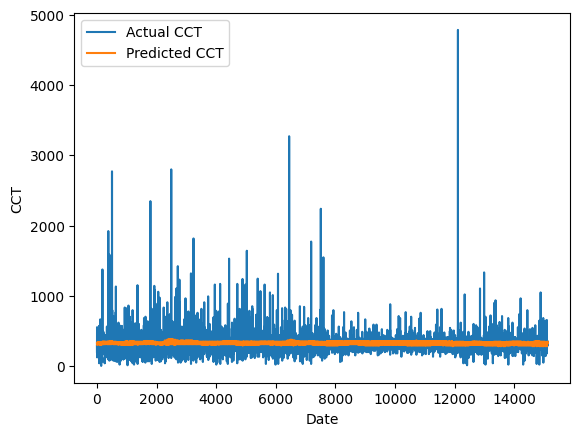

In [75]:
with torch.no_grad():
    predicted = model(X_train).to(torch.float32).cpu().numpy()

plt.plot(scaler.inverse_transform(y_train.to(torch.float32).cpu().numpy()), label='Actual CCT')
plt.plot(
    scaler.inverse_transform(predicted), 
    label='Predicted CCT')
plt.xlabel('Date')
plt.ylabel('CCT')
plt.legend()
plt.show()


/home/ethanc12/jems/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


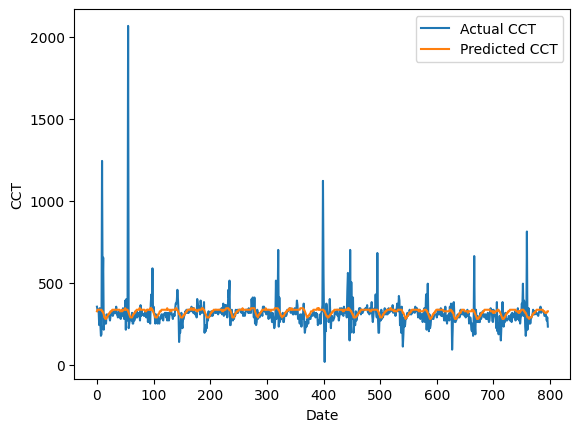

In [76]:
with torch.no_grad():
    predicted = model(X_test).to(torch.float32).cpu().numpy()

plt.plot(
    scaler.inverse_transform(y_test.to(torch.float32).cpu().numpy()), 
    label='Actual CCT')
plt.plot(
    scaler.inverse_transform(predicted), 
    label='Predicted CCT')
plt.xlabel('Date')
plt.ylabel('CCT')
plt.legend()
plt.show()


In [ ]:
# def assemble_output(all_preds: dict[str, pd.DataFrame]) -> pd.DataFrame:
#     """
#     Combine per-center predictions into the required wide format:
#     Month | Day | Interval | CV_A | Abd_A | Abd_Rate_A | CCT_A | ... x4
#     """
#     # Use center A as the skeleton for Month/Day/Interval
#     base = all_preds["A"][["date", "interval_time"]].copy()
#     base["Month"]    = "August"
#     base["Day"]      = base["date"].dt.day
#     base["Interval"] = base["interval_time"].apply(
#         lambda t: f"{t.hour:02d}:{t.minute:02d}:00"
#     )

#     for cc in CALL_CENTERS:
#         df = all_preds[cc].copy()
#         base[f"Calls_Offered_{cc}"]   = df["CV"].values
#         base[f"Abandoned_Calls_{cc}"] = df["Abandoned_Calls"].values
#         base[f"Abandoned_Rate_{cc}"]  = df["ABD"].values
#         base[f"CCT_{cc}"]             = df["CCT"].values

#     cols = ["Month", "Day", "Interval"]
#     for cc in CALL_CENTERS:
#         cols += [f"Calls_Offered_{cc}", f"Abandoned_Calls_{cc}",
#                  f"Abandoned_Rate_{cc}", f"CCT_{cc}"]

#     return base[cols].reset_index(drop=True)